#Setup

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install xgboost lightgbm shap -q

In [ ]:
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import shap
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42

#Load all 5 files

In [ ]:
BASE = "/content/drive/MyDrive/CPTAC Dataset"

mutation = pd.read_csv(f"{BASE}/Genomics/Human__CPTAC_COAD__WUSM__Mutation__GAIIx__03_01_2017__BCM__Gene__GATK_Pipeline.cbt",
                        sep="\t", index_col=0).T

scna = pd.read_csv(f"{BASE}/Genomics/Human__CPTAC_COAD__VU__SCNA__ExomeSeq__01_28_2016__BCM__Gene__BCM_CopyWriteR_GISTIC2.cct",
                    sep="\t", index_col=0).T

proteome_tumor = pd.read_csv(f"{BASE}/Proteomics/Human__CPTAC_COAD__PNNL__Proteome__TMT__03_01_2017__BCM__Gene__PNNL_Tumor_TMT_UnsharedLogRatio.cct",
                              sep="\t", index_col=0).T

clinical = pd.read_csv(f"{BASE}/Proteomics/Human__CPTAC_COAD__MS__Clinical__Clinical__03_01_2017__CPTAC__Clinical__BCM.tsi",
                        sep="\t", index_col=0).T

rnaseq = pd.read_csv(f"{BASE}/Transcriptomics/Human__CPTAC_COAD__UNC__RNAseq__HiSeq_RNA__03_01_2017__BCM__Gene__BCM_RSEM_UpperQuartile_log2.cct",
                      sep="\t", index_col=0).T

print("Proteome:", proteome_tumor.shape, "| RNA-seq:", rnaseq.shape,
      "| Mutation:", mutation.shape, "| SCNA:", scna.shape, "| Clinical:", clinical.shape)

Proteome: (97, 8067) | RNA-seq: (106, 13482) | Mutation: (106, 15174) | SCNA: (105, 25187) | Clinical: (110, 27)


#Common patients across all layers

In [ ]:
common_patients = sorted(set(proteome_tumor.index) & set(rnaseq.index) &
                          set(mutation.index) & set(scna.index) & set(clinical.index))
print("Common patients:", len(common_patients))

proteome_tumor = proteome_tumor.loc[common_patients]
rnaseq = rnaseq.loc[common_patients]
mutation = mutation.loc[common_patients]
scna = scna.loc[common_patients]
clinical = clinical.loc[common_patients]

Common patients: 95


#Target label (Early vs Late stage)

In [ ]:
stage_map = {"Stage I": "Early", "Stage II": "Early", "Stage III": "Late", "Stage IV": "Late"}
clinical["Stage_group"] = clinical["Stage"].map(stage_map)

valid_patients = clinical["Stage_group"].dropna().index
proteome_tumor = proteome_tumor.loc[valid_patients]
rnaseq = rnaseq.loc[valid_patients]
mutation = mutation.loc[valid_patients]
scna = scna.loc[valid_patients]
clinical = clinical.loc[valid_patients]

y = (clinical["Stage_group"] == "Late").astype(int)
print(y.value_counts())

Stage_group
0    49
1    46
Name: count, dtype: int64


#Preprocess & select top features per layer

In [ ]:
def preprocess_continuous(df, y, k=50):
    df = df.apply(pd.to_numeric, errors="coerce")
    df = df.dropna(axis=1, thresh=int(0.7*len(df)))
    imputer = SimpleImputer(strategy="median")
    df_imp = pd.DataFrame(imputer.fit_transform(df), index=df.index, columns=df.columns)
    selector = SelectKBest(f_classif, k=min(k, df_imp.shape[1]))
    selector.fit(df_imp, y)
    return df_imp[df_imp.columns[selector.get_support()]]

def preprocess_mutation(df, y, min_patients=3, k=50):
    df = df.apply(pd.to_numeric, errors="coerce").fillna(0)
    df = df.loc[:, df.sum(axis=0) >= min_patients]
    selector = SelectKBest(f_classif, k=min(k, df.shape[1]))
    selector.fit(df, y)
    return df[df.columns[selector.get_support()]]

prot_sel = preprocess_continuous(proteome_tumor, y, k=50)
rna_sel  = preprocess_continuous(rnaseq, y, k=50)
scna_sel = preprocess_continuous(scna, y, k=50)
mut_sel  = preprocess_mutation(mutation, y, k=50)

print("Selected -> Proteome:", prot_sel.shape[1], "| RNA-seq:", rna_sel.shape[1],
      "| SCNA:", scna_sel.shape[1], "| Mutation:", mut_sel.shape[1])

Selected -> Proteome: 50 | RNA-seq: 50 | SCNA: 50 | Mutation: 50


#Baseline: each layer alone (AUC)

In [ ]:
def evaluate_layer(X, y, name, model=None):
    if model is None:
        model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    print(f"{name:30s} AUC: {scores.mean():.3f} +/- {scores.std():.3f}")
    return scores.mean()

single_layer_auc = {}
single_layer_auc["Proteome only"] = evaluate_layer(prot_sel, y, "Proteome only")
single_layer_auc["RNA-seq only"]  = evaluate_layer(rna_sel, y, "RNA-seq only")
single_layer_auc["SCNA only"]     = evaluate_layer(scna_sel, y, "SCNA only")
single_layer_auc["Mutation only"] = evaluate_layer(mut_sel, y, "Mutation only")

Proteome only                  AUC: 0.844 +/- 0.092
RNA-seq only                   AUC: 0.729 +/- 0.224
SCNA only                      AUC: 0.637 +/- 0.167
Mutation only                  AUC: 0.898 +/- 0.069


#Early fusion (concatenate all layers)

In [ ]:
X_fused = pd.concat([prot_sel.add_prefix("PROT_"), rna_sel.add_prefix("RNA_"),
                      scna_sel.add_prefix("SCNA_"), mut_sel.add_prefix("MUT_")], axis=1)
print("Fused shape:", X_fused.shape)

models = {
    "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=3, eval_metric="logloss", random_state=RANDOM_STATE),
    "LightGBM": LGBMClassifier(n_estimators=300, max_depth=3, random_state=RANDOM_STATE, verbose=-1),
}

fused_scores = {name: evaluate_layer(X_fused, y, f"Early Fusion ({name})", model=m) for name, m in models.items()}
best_model_name = max(fused_scores, key=fused_scores.get)
print("\nBest early-fusion model:", best_model_name)

Fused shape: (95, 200)
Early Fusion (RandomForest)    AUC: 0.773 +/- 0.165
Early Fusion (XGBoost)         AUC: 0.740 +/- 0.156
Early Fusion (LightGBM)        AUC: 0.818 +/- 0.136

Best early-fusion model: LightGBM


#3-layer fusion (drop the weakest layer, SCNA)

In [ ]:
X_fused_3layer = pd.concat([prot_sel.add_prefix("PROT_"), rna_sel.add_prefix("RNA_"),
                             mut_sel.add_prefix("MUT_")], axis=1)
auc_3layer = evaluate_layer(X_fused_3layer, y, "Fusion (no SCNA)", model=models[best_model_name])

Fusion (no SCNA)               AUC: 0.776 +/- 0.136


#Late fusion (stacking predictions instead of raw features)


In [ ]:
def get_oof_predictions(X, y, model):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    return cross_val_predict(model, X, y, cv=cv, method="predict_proba")[:, 1]

layer_models = {
    "Proteome": (prot_sel, RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
    "RNA-seq": (rna_sel, RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
    "SCNA": (scna_sel, RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
    "Mutation": (mut_sel, RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)),
}

stacked_features = pd.DataFrame(index=y.index)
for name, (X, model) in layer_models.items():
    stacked_features[f"{name}_pred"] = get_oof_predictions(X, y, model)

meta_model = LogisticRegression()
late_fusion_auc = evaluate_layer(stacked_features, y, "Late Fusion (Stacked)", model=meta_model)

Late Fusion (Stacked)          AUC: 0.922 +/- 0.074


#Full comparison across every approach

Late Fusion (stacked)     0.922
Mutation only             0.898
Proteome only             0.844
Early Fusion (all 4)      0.818
Early Fusion (no SCNA)    0.776
RNA-seq only              0.729
SCNA only                 0.637
dtype: float64


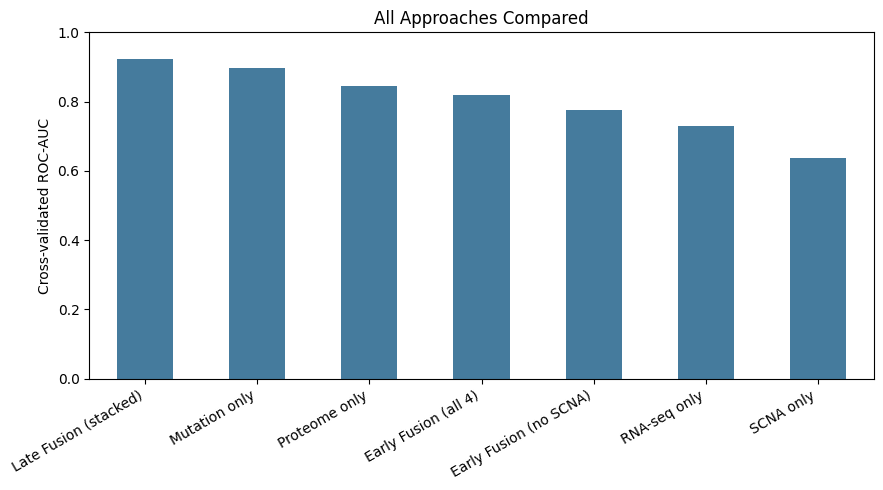

In [ ]:
final_comparison = {**single_layer_auc,
                     "Early Fusion (all 4)": fused_scores[best_model_name],
                     "Early Fusion (no SCNA)": auc_3layer,
                     "Late Fusion (stacked)": late_fusion_auc}

result_series = pd.Series(final_comparison).sort_values(ascending=False)
print(result_series.round(3))

plt.figure(figsize=(9,5))
result_series.plot(kind="bar", color="#457b9d")
plt.ylabel("Cross-validated ROC-AUC")
plt.title("All Approaches Compared")
plt.xticks(rotation=30, ha="right")
plt.ylim(0,1)
plt.tight_layout()
plt.show()

#Multi-metric comparison (Accuracy, Precision, Recall, F1, AUC)


In [ ]:
from sklearn.model_selection import cross_validate

def evaluate_multi_metric_stacked(X, y, model, name):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"accuracy": "accuracy", "precision": "precision", "recall": "recall", "f1": "f1", "auc": "roc_auc"}
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    row = {m: scores[f"test_{m}"].mean() for m in scoring}
    row["name"] = name
    return row, scores

late_fusion_row, late_fusion_scores = evaluate_multi_metric_stacked(stacked_features, y, LogisticRegression(), "Late Fusion (Stacked)")

comparison_df_full = pd.concat([
    comparison_df,
    pd.DataFrame([late_fusion_row]).set_index("name")[["accuracy","precision","recall","f1","auc"]]
])
print(comparison_df_full.round(3))

                       accuracy  precision  recall     f1    auc
name                                                            
Proteome only             0.758      0.805   0.722  0.739  0.844
RNA-seq only              0.663      0.702   0.633  0.654  0.729
SCNA only                 0.611      0.577   0.618  0.590  0.637
Mutation only             0.800      0.734   0.960  0.829  0.898
Early Fusion              0.747      0.782   0.700  0.724  0.818
Late Fusion (Stacked)     0.874      0.838   0.940  0.880  0.922


#Statistical significance test (fused vs each single layer)

In [ ]:
fused_folds = raw_fold_scores["Early Fusion"]
print("Paired t-test: Early Fusion vs each single layer\n")
for name in ["Proteome only", "RNA-seq only", "SCNA only", "Mutation only"]:
    t_stat, p_value = stats.ttest_rel(fused_folds, raw_fold_scores[name])
    diff = fused_folds.mean() - raw_fold_scores[name].mean()
    sig = "significant (p<0.05)" if p_value < 0.05 else "not significant"
    print(f"vs {name:15s} | AUC diff: {diff:+.3f} | p={p_value:.3f} | {sig}")

Paired t-test: Early Fusion vs each single layer

vs Proteome only   | AUC diff: -0.027 | p=0.621 | not significant
vs RNA-seq only    | AUC diff: +0.089 | p=0.228 | not significant
vs SCNA only       | AUC diff: +0.181 | p=0.169 | not significant
vs Mutation only   | AUC diff: -0.080 | p=0.393 | not significant


#SHAP biomarker extraction (on whichever fusion approach performed best)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


      feature  importance     omics_layer gene_name
  PROT_RASAL3    1.502378      Proteomics    RASAL3
    PROT_RNMT    1.325596      Proteomics      RNMT
    PROT_HMX3    1.181166      Proteomics      HMX3
 PROT_C1orf27    1.068012      Proteomics   C1orf27
    SCNA_LEPR    1.026417  Genomics (CNV)      LEPR
    PROT_JUND    0.973026      Proteomics      JUND
   PROT_SEPT1    0.953128      Proteomics     SEPT1
   PROT_PTK2B    0.708463      Proteomics     PTK2B
  RNA_RASA4CP    0.702940 Transcriptomics   RASA4CP
     RNA_INMT    0.659828 Transcriptomics      INMT
    PROT_PLS1    0.652150      Proteomics      PLS1
  PROT_MAP2K2    0.651173      Proteomics    MAP2K2
    PROT_CDK7    0.615347      Proteomics      CDK7
     RNA_CMBL    0.547912 Transcriptomics      CMBL
    PROT_RBM3    0.546160      Proteomics      RBM3
SCNA_SCGB1B2P    0.523705  Genomics (CNV)  SCGB1B2P
    RNA_PRRG2    0.497572 Transcriptomics     PRRG2
   PROT_GNG10    0.472143      Proteomics     GNG10
   PROT_OGDH

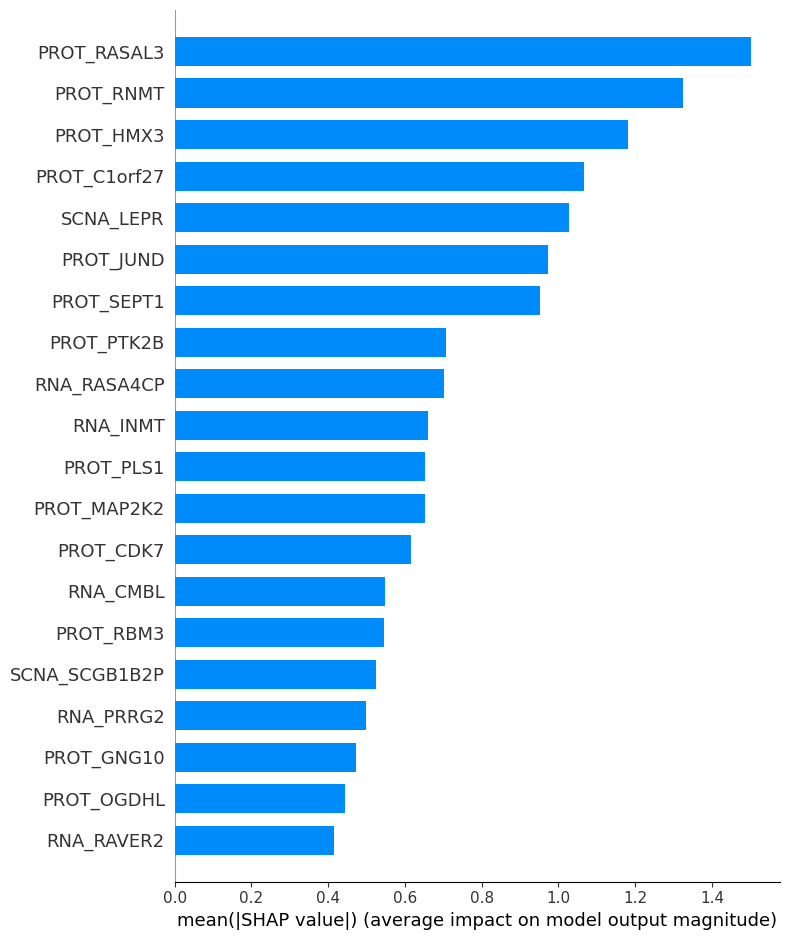

In [ ]:
best_model = models[best_model_name]
best_model.fit(X_fused, y)

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_fused)
sv = shap_values[1] if isinstance(shap_values, list) else shap_values

mean_abs_shap = np.abs(sv).mean(axis=0)
biomarker_table = pd.DataFrame({"feature": X_fused.columns, "importance": mean_abs_shap})
biomarker_table["omics_layer"] = biomarker_table["feature"].apply(
    lambda x: {"PROT": "Proteomics", "RNA": "Transcriptomics",
               "SCNA": "Genomics (CNV)", "MUT": "Genomics (Mutation)"}[x.split("_")[0]])
biomarker_table["gene_name"] = biomarker_table["feature"].apply(lambda x: x.split("_", 1)[1])
biomarker_table = biomarker_table.sort_values("importance", ascending=False).reset_index(drop=True)

print(biomarker_table.head(20).to_string(index=False))

shap.summary_plot(sv, X_fused, plot_type="bar", max_display=20)


#Layer-level contribution(Early Fusion)

omics_layer
Proteomics             63.1
Transcriptomics        29.0
Genomics (CNV)          7.9
Genomics (Mutation)     0.0
Name: importance, dtype: float64


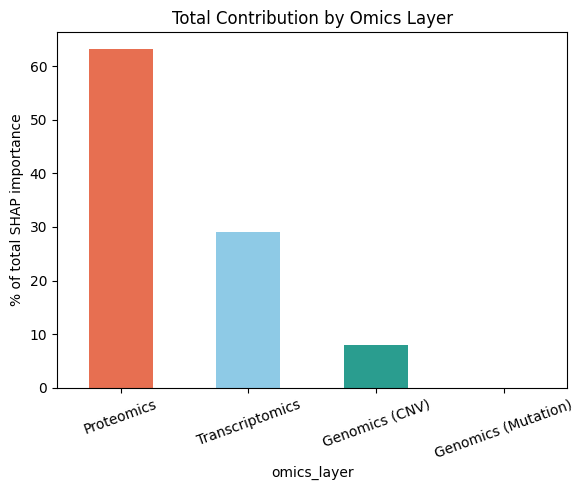

Saved biomarker ranking and performance comparison to Drive.


In [ ]:
layer_contribution = biomarker_table.groupby("omics_layer")["importance"].sum().sort_values(ascending=False)
layer_contribution_pct = 100 * layer_contribution / layer_contribution.sum()
print(layer_contribution_pct.round(1))

layer_contribution_pct.plot(kind="bar", figsize=(6,5), color=["#e76f51","#8ecae6","#2a9d8f","#f4a261"])
plt.ylabel("% of total SHAP importance")
plt.title("Total Contribution by Omics Layer")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

biomarker_table.to_csv(f"{BASE}/fused_model_biomarker_ranking.csv", index=False)
comparison_df.to_csv(f"{BASE}/performance_comparison.csv")
print("Saved biomarker ranking and performance comparison to Drive.")

#Significance test: Late Fusion vs. Mutation

In [ ]:
mutation_folds = raw_fold_scores["Mutation only"]
late_fusion_folds = late_fusion_scores["test_auc"]

t_stat, p_value = stats.ttest_rel(late_fusion_folds, mutation_folds)
diff = late_fusion_folds.mean() - mutation_folds.mean()
sig = "significant (p<0.05)" if p_value < 0.05 else "not significant (small-sample caveat)"

print(f"Late Fusion vs Mutation only | AUC diff: {diff:+.3f} | p={p_value:.3f} | {sig}")

Late Fusion vs Mutation only | AUC diff: +0.024 | p=0.450 | not significant (small-sample caveat)


#Meta-model learned weights

Meta-model learned weight per omics layer:

Mutation_pred    3.138220
Proteome_pred    2.005351
RNA-seq_pred     0.881127
SCNA_pred        0.614638
dtype: float64


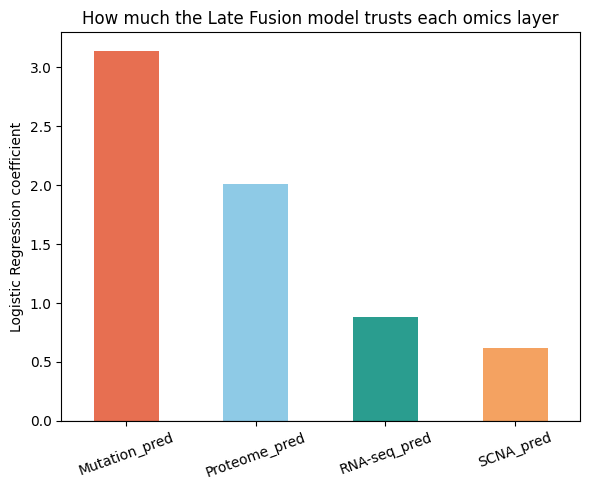

In [ ]:
# Fit the meta-model on the full stacked predictions
meta_model_fitted = LogisticRegression()
meta_model_fitted.fit(stacked_features, y)

layer_weights = pd.Series(meta_model_fitted.coef_[0], index=stacked_features.columns).sort_values(ascending=False)
print("Meta-model learned weight per omics layer:\n")
print(layer_weights)

plt.figure(figsize=(6,5))
layer_weights.plot(kind="bar", color=["#e76f51","#8ecae6","#2a9d8f","#f4a261"])
plt.ylabel("Logistic Regression coefficient")
plt.title("How much the Late Fusion model trusts each omics layer")
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:
def get_shap_biomarkers(X, y, model, layer_name):
    model.fit(X, y)
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)

    if isinstance(shap_values, list):
        sv_layer = shap_values[1]
    elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        sv_layer = shap_values[:, :, 1]
    else:
        sv_layer = shap_values

    mean_abs_shap = np.abs(sv_layer).mean(axis=0)
    mean_abs_shap = np.ravel(mean_abs_shap)

    table = pd.DataFrame({"gene_name": X.columns, "importance": mean_abs_shap, "omics_layer": layer_name})
    return table.sort_values("importance", ascending=False).reset_index(drop=True)

In [ ]:
mutation_biomarkers = get_shap_biomarkers(mut_sel, y, RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), "Genomics (Mutation)")
proteome_biomarkers = get_shap_biomarkers(prot_sel, y, RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), "Proteomics")
rna_biomarkers  = get_shap_biomarkers(rna_sel, y, RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), "Transcriptomics")
scna_biomarkers = get_shap_biomarkers(scna_sel, y, RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE), "Genomics (CNV)")

late_fusion_biomarker_table = pd.concat([mutation_biomarkers, proteome_biomarkers]).sort_values("importance", ascending=False).reset_index(drop=True)

print(late_fusion_biomarker_table.head(20).to_string(index=False))

late_fusion_biomarker_table.to_csv(f"{BASE}/late_fusion_biomarker_ranking.csv", index=False)
print("Saved late-fusion-aligned biomarker ranking to Drive.")

gene_name  importance         omics_layer
    LAMC3    0.044758 Genomics (Mutation)
     RELN    0.043403 Genomics (Mutation)
   RASAL3    0.042257          Proteomics
    AHNAK    0.039388 Genomics (Mutation)
     RYR1    0.030351 Genomics (Mutation)
    NPAP1    0.029965 Genomics (Mutation)
    GSK3A    0.026875          Proteomics
     PLS1    0.026166          Proteomics
     FXR1    0.025689 Genomics (Mutation)
  COL22A1    0.025510 Genomics (Mutation)
   ZNF318    0.021968 Genomics (Mutation)
    SEPT1    0.021670          Proteomics
   IGFALS    0.020994 Genomics (Mutation)
  PLEKHH1    0.020877 Genomics (Mutation)
  C1orf27    0.020591          Proteomics
     RBP3    0.019359 Genomics (Mutation)
     RNMT    0.019331          Proteomics
   STK38L    0.018627          Proteomics
    SP140    0.018417 Genomics (Mutation)
    NUTM1    0.017909 Genomics (Mutation)
Saved late-fusion-aligned biomarker ranking to Drive.


#Pathway Enrichment

In [ ]:
!pip install gseapy -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.9/689.9 kB 9.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd

biomarker_table = pd.read_csv(f"{BASE}/late_fusion_biomarker_ranking.csv")

top_genes = biomarker_table.drop_duplicates(subset="gene_name").head(30)["gene_name"].tolist()
print("Genes going into enrichment:\n", top_genes)

Genes going into enrichment:
 ['LAMC3', 'RELN', 'RASAL3', 'AHNAK', 'RYR1', 'NPAP1', 'GSK3A', 'PLS1', 'FXR1', 'COL22A1', 'ZNF318', 'SEPT1', 'IGFALS', 'PLEKHH1', 'C1orf27', 'RBP3', 'RNMT', 'STK38L', 'SP140', 'NUTM1', 'KRT17', 'SASS6', 'COL4A6', 'VPS41', 'PTK2B', 'ANKRD62', 'HMX3', 'HPS3', 'CDK7', 'CRELD1']


In [ ]:
import gseapy as gp

enr = gp.enrichr(
    gene_list=top_genes,
    gene_sets=["KEGG_2021_Human", "GO_Biological_Process_2021", "Reactome_2022"],
    organism="human",
    outdir=None
)

results = enr.results.sort_values("Adjusted P-value")
results[["Gene_set", "Term", "Overlap", "Adjusted P-value", "Genes"]].head(20)

,Gene_set,Term,Overlap,Adjusted P-value,Genes
0,KEGG_2021_Human,ECM-receptor interaction,3/88,0.012572,RELN;LAMC3;COL4A6
434,Reactome_2022,RNA Pol II CTD Phosphorylation And Interaction...,2/27,0.031215,CDK7;RNMT
436,Reactome_2022,mRNA Capping R-HSA-72086,2/29,0.031215,CDK7;RNMT
435,Reactome_2022,MET Promotes Cell Motility R-HSA-8875878,2/28,0.031215,LAMC3;RNMT
433,Reactome_2022,MET Activates PTK2 Signaling R-HSA-8874081,2/17,0.031215,LAMC3;RNMT
43,GO_Biological_Process_2021,"positive regulation of synaptic transmission, ...",2/18,0.042839,RELN;PTK2B
41,GO_Biological_Process_2021,regulation of cation channel activity (GO:2001...,3/89,0.042839,RELN;AHNAK;PTK2B
42,GO_Biological_Process_2021,positive regulation of excitatory postsynaptic...,2/18,0.042839,RELN;PTK2B
45,GO_Biological_Process_2021,protein phosphorylation (GO:0006468),5/496,0.051404,GSK3A;CDK7;RELN;STK38L;PTK2B
46,GO_Biological_Process_2021,7-methylguanosine mRNA capping (GO:0006370),2/32,0.051404,CDK7;RNMT


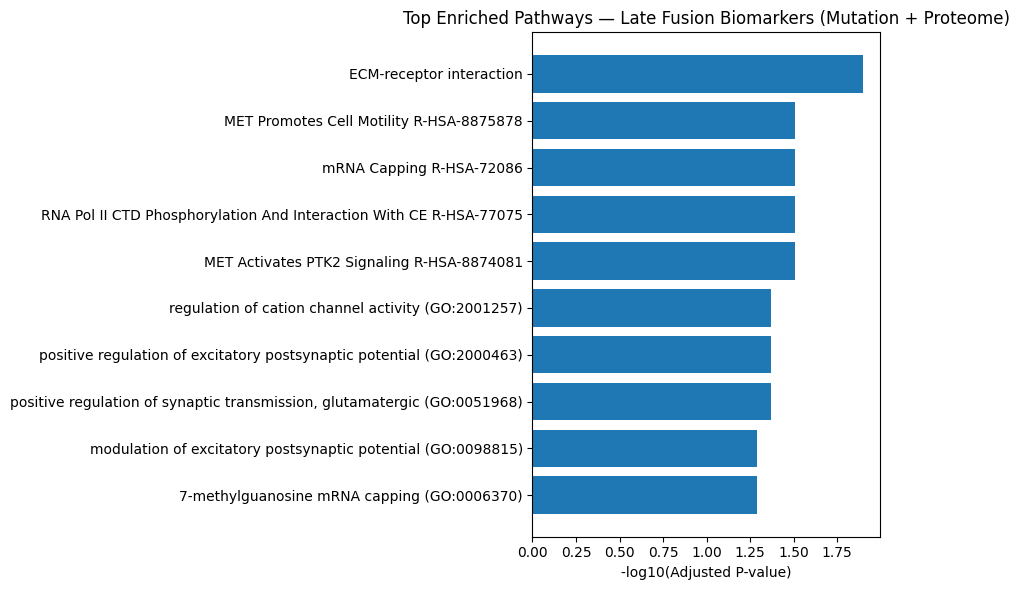

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

top_pathways = results.sort_values("Adjusted P-value").head(10)

plt.figure(figsize=(9,6))
plt.barh(top_pathways["Term"], -np.log10(top_pathways["Adjusted P-value"]))
plt.xlabel("-log10(Adjusted P-value)")
plt.title("Top Enriched Pathways — Late Fusion Biomarkers (Mutation + Proteome)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
results.to_csv(f"{BASE}/pathway_enrichment_late_fusion.csv", index=False)
print("Saved pathway enrichment results to Drive.")

Saved pathway enrichment results to Drive.


In [ ]:
key_pathways = ["ECM-receptor interaction",
                 "MET Promotes Cell Motility R-HSA-8875878",
                 "MET Activates PTK2 Signaling R-HSA-8874081"]

supporting_table = results[results["Term"].isin(key_pathways)][["Term", "Genes", "Adjusted P-value"]]
supporting_table = supporting_table.sort_values("Adjusted P-value")
print(supporting_table.to_string(index=False))

supporting_table.to_csv(f"{BASE}/slide_pathway_table.csv", index=False)

                                      Term             Genes  Adjusted P-value
                  ECM-receptor interaction RELN;LAMC3;COL4A6          0.012572
  MET Promotes Cell Motility R-HSA-8875878        LAMC3;RNMT          0.031215
MET Activates PTK2 Signaling R-HSA-8874081        LAMC3;RNMT          0.031215
